In [1]:
from pathlib import Path
import torch
import torch.nn as nn
from torchvision import models, transforms
from ultralytics import YOLO
from PIL import Image
import cv2
import numpy as np
import matplotlib.pyplot as plt

DATASET_ROOT = Path("..") / "smartvision_dataset"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load YOLO (detection)
yolo_model = YOLO("../models/yolov8_best.pt")

# Load EfficientNetB0 (your selected primary classifier)
NUM_CLASSES = 25
efficientnet = models.efficientnet_b0(weights=None)
efficientnet.classifier = nn.Sequential(
    nn.Dropout(0.4), nn.Linear(1280, 256), nn.BatchNorm1d(256),
    nn.ReLU(), nn.Dropout(0.4), nn.Linear(256, NUM_CLASSES)
)
efficientnet.load_state_dict(torch.load("../models/efficientnetb0_best.pth", map_location=device))
efficientnet = efficientnet.to(device).eval()

# Class names (alphabetical order — matches classifier's ImageFolder training order)
import json
with open("../models/classification_class_to_idx.json", "r") as f:
    class_to_idx = json.load(f)
idx_to_class = {v: k for k, v in class_to_idx.items()}

# YOLO class names (numeric COCO-style order — different order than classifier!)
yolo_class_names = yolo_model.names

print("Both models loaded.")
print(f"Classifier classes: {len(idx_to_class)}")
print(f"YOLO classes: {len(yolo_class_names)}")

Both models loaded.
Classifier classes: 25
YOLO classes: 25


In [2]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

classify_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

def run_pipeline(image_path, conf_threshold=0.5, verify_with_classifier=True):
    """
    End-to-end pipeline: YOLO detects objects -> optional CNN classification
    verification on each cropped detection -> structured results.
    """
    # Step 1: YOLO detection (NMS + confidence filtering happen internally,
    # but we set them explicitly here per Step 4.2's requirements)
    results = yolo_model.predict(
        source=str(image_path),
        conf=conf_threshold,   # confidence threshold filter (>50%)
        iou=0.45,               # NMS IoU threshold (removes duplicate/overlapping boxes)
        imgsz=640,
        verbose=False
    )[0]

    original_img = cv2.imread(str(image_path))
    img_h, img_w = original_img.shape[:2]

    detections = []

    for box in results.boxes:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
        yolo_class_id = int(box.cls[0].item())
        yolo_conf = float(box.conf[0].item())
        yolo_label = yolo_class_names[yolo_class_id]

        detection = {
            "bbox": [int(x1), int(y1), int(x2), int(y2)],
            "yolo_label": yolo_label,
            "yolo_confidence": round(yolo_conf, 4),
        }

        # Step 2: Optional classifier verification on the cropped detection
        if verify_with_classifier:
            crop = original_img[max(0,int(y1)):int(y2), max(0,int(x1)):int(x2)]
            if crop.size > 0:
                crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
                crop_pil = Image.fromarray(crop_rgb)
                input_tensor = classify_transform(crop_pil).unsqueeze(0).to(device)

                with torch.no_grad():
                    output = efficientnet(input_tensor)
                    probs = torch.softmax(output, dim=1)
                    conf, pred_idx = torch.max(probs, 1)

                detection["classifier_label"] = idx_to_class[pred_idx.item()]
                detection["classifier_confidence"] = round(conf.item(), 4)
                detection["agreement"] = (yolo_label == detection["classifier_label"])

        detections.append(detection)

    return detections, original_img

print("Pipeline function ready.")

Pipeline function ready.


Image: image_001125.jpg
Detections: 5

YOLO: horse (0.86) | Classifier: horse (0.99) | Agree: ✓
YOLO: person (0.83) | Classifier: dog (0.72) | Agree: ✗
YOLO: person (0.67) | Classifier: horse (0.86) | Agree: ✗
YOLO: horse (0.56) | Classifier: horse (0.67) | Agree: ✓
YOLO: person (0.54) | Classifier: dog (0.62) | Agree: ✗


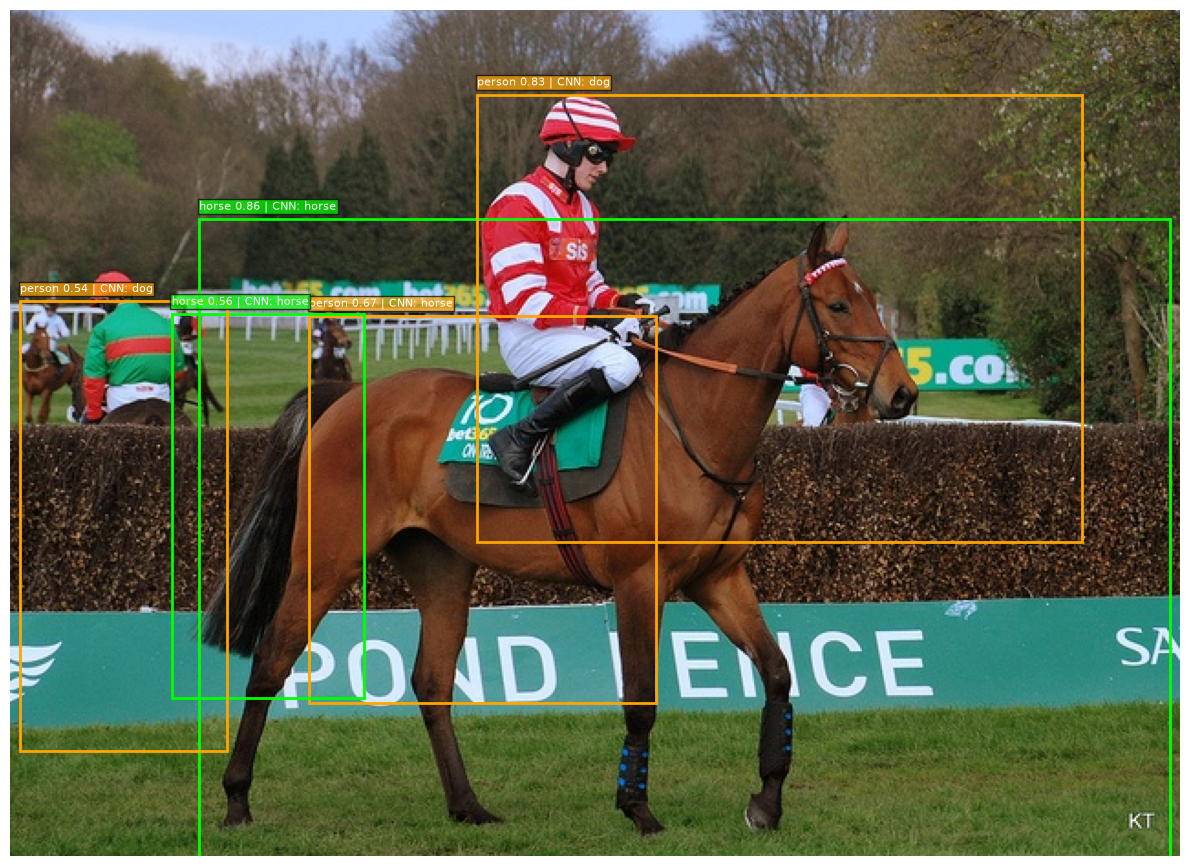

In [3]:
import random

test_images_dir = DATASET_ROOT / "detection" / "images" / "test"
sample_image = random.choice(list(test_images_dir.glob("*.jpg")))

detections, original_img = run_pipeline(sample_image, conf_threshold=0.5, verify_with_classifier=True)

print(f"Image: {sample_image.name}")
print(f"Detections: {len(detections)}\n")
for d in detections:
    agree_symbol = "✓" if d.get("agreement") else "✗"
    print(f"YOLO: {d['yolo_label']} ({d['yolo_confidence']:.2f}) | "
          f"Classifier: {d.get('classifier_label')} ({d.get('classifier_confidence', 0):.2f}) | "
          f"Agree: {agree_symbol}")

# Visualize with both labels
img_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
ax.imshow(img_rgb)

for d in detections:
    x1, y1, x2, y2 = d["bbox"]
    color = "lime" if d.get("agreement") else "orange"
    rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor=color, linewidth=2)
    ax.add_patch(rect)
    label_text = f"{d['yolo_label']} {d['yolo_confidence']:.2f}"
    if verify_with_classifier := d.get("classifier_label"):
        label_text += f" | CNN: {d['classifier_label']}"
    ax.text(x1, max(y1-5, 10), label_text, color="white", fontsize=8,
             bbox=dict(facecolor=color, alpha=0.7, pad=1))

ax.axis("off")
plt.tight_layout()
plt.savefig("../results/eda_plots/pipeline_test.png")
plt.show()

In [4]:
import time

# Dynamic quantization: converts Linear layers to int8, reducing size and speeding up CPU inference
efficientnet_quantized = torch.quantization.quantize_dynamic(
    efficientnet, {nn.Linear}, dtype=torch.qint8
)

# Compare model sizes
import os
torch.save(efficientnet.state_dict(), "../models/temp_original.pth")
torch.save(efficientnet_quantized.state_dict(), "../models/temp_quantized.pth")

original_size = os.path.getsize("../models/temp_original.pth") / (1024*1024)
quantized_size = os.path.getsize("../models/temp_quantized.pth") / (1024*1024)
print(f"Original size: {original_size:.2f} MB")
print(f"Quantized size: {quantized_size:.2f} MB")

# Compare inference speed on a batch
dummy_input = torch.randn(1, 3, 224, 224)

with torch.no_grad():
    start = time.time()
    for _ in range(20):
        efficientnet(dummy_input)
    original_time = (time.time() - start) / 20

    start = time.time()
    for _ in range(20):
        efficientnet_quantized(dummy_input)
    quantized_time = (time.time() - start) / 20

print(f"\nOriginal avg inference: {original_time*1000:.2f} ms")
print(f"Quantized avg inference: {quantized_time*1000:.2f} ms")
print(f"Speedup: {original_time/quantized_time:.2f}x")

os.remove("../models/temp_original.pth")
os.remove("../models/temp_quantized.pth")

C:\Users\Admin\AppData\Local\Temp\ipykernel_4104\3099922019.py:4: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  efficientnet_quantized = torch.quantization.quantize_dynamic(


Original size: 16.85 MB
Quantized size: 15.90 MB

Original avg inference: 12.88 ms
Quantized avg inference: 10.16 ms
Speedup: 1.27x


In [5]:
torch.save(efficientnet_quantized.state_dict(), "../models/efficientnetb0_quantized.pth")
print("Quantized model saved.")

Quantized model saved.
